# TP1 (a completer) : K-means + ACP — *Wine*

Remplacez chaque `...` et chaque `# TODO`. Le corrige est dans
`../notebooks/TP1_kmeans_acp.ipynb` (a ne consulter qu'en dernier recours).

**Objectif.** Retrouver, par clustering, les **3 cepages** de 178 vins decrits
par 13 mesures chimiques, sans utiliser l'etiquette ; puis valider et qualifier.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Matplotlib is building the font cache; this may take a moment.


Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import load_wine
ds = load_wine(as_frame=True)
X = ds.data
cepage = ds.target      # garde de cote pour la validation
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 1. Exploration
**Consigne.** Affichez la moyenne et l'ecart-type de chaque variable pour
constater les differences d'echelle.

In [3]:
# Statistiques descriptives : moyenne et ecart-type de chaque variable.
# Les ordres de grandeur sont tres differents (ex. proline ~ centaines,
# alcohol ~ dizaines) -> il faudra standardiser avant le clustering.
stats = X.describe().T[["mean", "std"]]
stats

,mean,std
alcohol,13.000618,0.811827
malic_acid,2.336348,1.117146
ash,2.366517,0.274344
alcalinity_of_ash,19.494944,3.339564
magnesium,99.741573,14.282484
total_phenols,2.295112,0.625851
flavanoids,2.029270,0.998859
nonflavanoid_phenols,0.361854,0.124453
proanthocyanins,1.590899,0.572359
color_intensity,5.058090,2.318286


## 2.a Standardisation
**Consigne.** Standardisez `X` (moyenne 0, ecart-type 1) avec `StandardScaler`.

In [4]:
from sklearn.preprocessing import StandardScaler

# Standardisation : chaque variable a moyenne 0 et ecart-type 1,
# pour que toutes pesent autant dans le calcul des distances.
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

## 2.b Choisir k
**Consigne.** Pour `k` de 2 a 8, entrainez un `KMeans` et stockez l'inertie
(`.inertia_`) et la silhouette (`silhouette_score`). Tracez les deux courbes et
deduisez `k_best` (k qui maximise la silhouette).

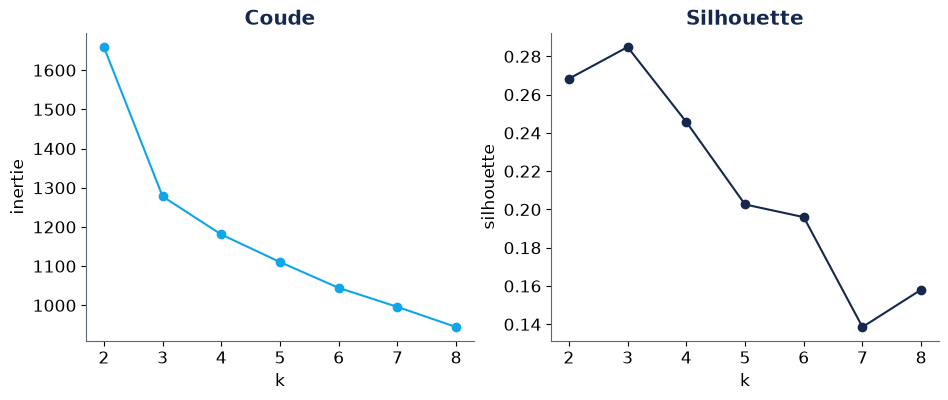

k retenu : 3


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inerties, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
    inerties.append(km.inertia_)                          # inertie (coude)
    silhouettes.append(silhouette_score(X_std, km.labels_))  # silhouette

k_best = list(ks)[int(np.argmax(silhouettes))]            # k de meilleure silhouette

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inerties, "-o", color=ACCENT)
ax1.set(title="Coude", xlabel="k", ylabel="inertie")
ax2.plot(list(ks), silhouettes, "-o", color=NAVY)
ax2.set(title="Silhouette", xlabel="k", ylabel="silhouette")
plt.show()
print("k retenu :", k_best)

## 3. Evaluation + validation
**Consigne.** Entrainez le modele final avec `k_best`. Affichez l'inertie, la
silhouette, puis **validez** : calculez l'`adjusted_rand_score` entre `cepage` et
les clusters, et affichez le `pd.crosstab`.

In [6]:
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=k_best, n_init=10, random_state=0).fit(X_std)
labels = km.labels_

# Evaluation interne (sans etiquette) + validation externe (avec les vrais cepages).
print(f"Inertie         : {km.inertia_:.1f}")
print(f"Silhouette      : {silhouette_score(X_std, labels):.3f}")
print(f"ARI (vs cepage) : {adjusted_rand_score(cepage, labels):.3f}")

# Tableau croise : chaque cluster doit correspondre majoritairement a un cepage.
pd.crosstab(labels, cepage, rownames=["cluster"], colnames=["cepage reel"])

Inertie         : 1277.9
Silhouette      : 0.285
ARI (vs cepage) : 0.897


cepage reel,0,1,2
cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


## 4. Visualisation ACP
**Consigne.** Projetez `X_std` en 2D avec `PCA(n_components=2)`, puis tracez un
nuage de points colore par cluster (ajoutez les centres si vous le souhaitez).

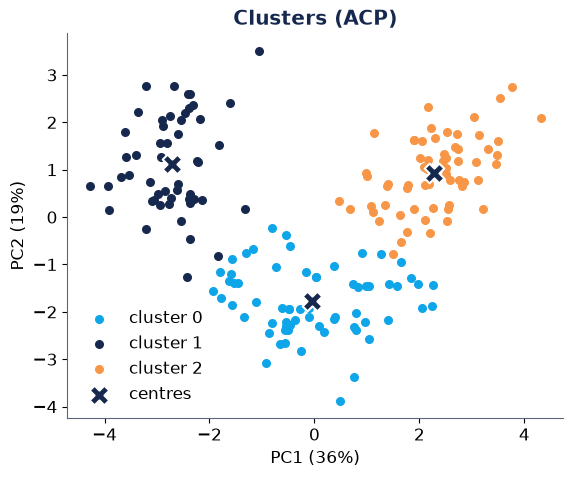

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_std)        # projection 2D
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(6.4, 5))
for c in sorted(np.unique(labels)):
    m = labels == c
    ax.scatter(coords[m, 0], coords[m, 1], s=30,
               color=PALETTE[c % len(PALETTE)], label=f"cluster {c}")
# Centres des clusters projetes dans le meme plan ACP.
centres = pca.transform(km.cluster_centers_)
ax.scatter(centres[:, 0], centres[:, 1], marker="X", s=200,
           c=NAVY, edgecolor="white", linewidths=1.5, label="centres")
ax.set(title="Clusters (ACP)", xlabel=f"PC1 ({var[0]:.0%})", ylabel=f"PC2 ({var[1]:.0%})")
ax.legend(frameon=False)
plt.show()

## 5 & 6. Integration + qualification
**Consigne.** Ajoutez la colonne `cluster` a une copie de `X`, puis calculez le
profil moyen (`groupby`) des variables `alcohol`, `color_intensity`,
`flavanoids`, `proline` par cluster. Commentez les profils.

In [8]:
vins = X.copy()
vins["cluster"] = labels
cles = ["alcohol", "color_intensity", "flavanoids", "proline"]
# Profil moyen de chaque cluster sur les variables cles -> base de la qualification.
profil = vins.groupby("cluster")[cles].mean()
profil

,alcohol,color_intensity,flavanoids,proline
cluster,,,,
0,12.250923,2.973077,2.050000,510.169231
1,13.134118,7.234706,0.818824,619.058824
2,13.676774,5.453548,3.003226,1100.225806


## 7. Aller plus loin : le clustering hierarchique (CAH)

K-means n'est pas la seule methode de clustering. La **Classification Ascendante
Hierarchique (CAH)** procede autrement :

1. au depart, **chaque vin est seul** dans son cluster ;
2. a chaque etape, on **fusionne les deux clusters les plus proches** ;
3. on continue jusqu'a n'avoir **qu'un seul cluster**.

L'historique des fusions se lit sur un **dendrogramme** : on le "coupe" a la
hauteur voulue pour obtenir k clusters. Avantage : pas besoin de fixer k a
l'avance, et la structure est visible.

**Consigne.** Tracez le dendrogramme (methode de Ward sur `X_std`), puis
recuperez 3 clusters avec `AgglomerativeClustering` et comparez-les aux clusters
K-means et aux vrais cepages (ARI).

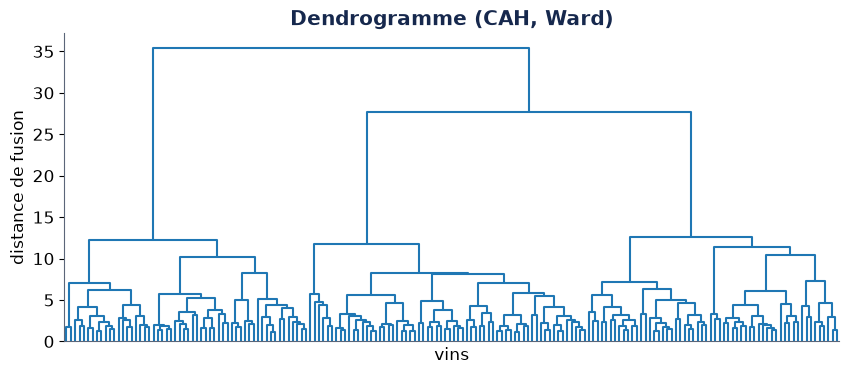

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Matrice de liaison (linkage) par la methode de Ward sur les donnees standardisees
Z = linkage(X_std, method="ward")

# 2. Dendrogramme
fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(Z, no_labels=True, color_threshold=0, ax=ax)
ax.set(title="Dendrogramme (CAH, Ward)", xlabel="vins", ylabel="distance de fusion")
plt.show()

In [10]:
from sklearn.cluster import AgglomerativeClustering

# 3. Couper l'arbre pour obtenir 3 clusters
cah = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_cah = cah.fit_predict(X_std)

# 4. Comparer : CAH vs K-means, et CAH vs vrais cepages (adjusted_rand_score)
print(f"ARI CAH vs K-means : {adjusted_rand_score(labels, labels_cah):.3f}")
print(f"ARI CAH vs cepage  : {adjusted_rand_score(cepage, labels_cah):.3f}")
pd.crosstab(labels_cah, cepage, rownames=["CAH"], colnames=["cepage reel"])

ARI CAH vs K-means : 0.853
ARI CAH vs cepage  : 0.790


cepage reel,0,1,2
CAH,,,
0,0,58,0
1,0,8,48
2,59,5,0


## A rendre
- Le `k` retenu et sa justification (coude + silhouette).
- L'ARI obtenu et votre interpretation du tableau croise.
- Une phrase de qualification par cluster.
- La comparaison **K-means vs CAH** (ARI) et ce que montre le dendrogramme.

**Bonus.** Refaites l'analyse **sans** standardisation : que devient l'ARI ?